# Exploratory analysis — biomedical-rag-bench

The **exploratory** notebook (the scrappy first of two). Its job is to *de-risk* the polished
notebook: first establish the data is trustworthy, then sketch the headline figures. It imports
the one tested loader (`eval/analysis/load.py`) — no load / dedup / reshape logic lives in cells.

Two steps, in this order on purpose:
- **Step 1 — the data: grain, dimensions, checks (*no charts*).** Can I *trust* this? Each
  dimension is shown with its realized value and linked to its canonical explanation in the READMEs.
- **Step 2 — metrics & insights (*charts*).** What does it *say*?

Run with the `eval` extra: `uv run --extra eval jupyter lab eval/analysis/explore.ipynb`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1]))  # repo root — this notebook lives in eval/analysis/

import pandas as pd
from eval.analysis.load import load, load_raw

df = load()
print(f"{len(df)} canonical rows · {df['retriever'].nunique()} retrievers · {df['type_id'].nunique()} types")

593 canonical rows · 6 retrievers · 10 types


## Step 1 — The data: grain, dimensions, checks (no charts)

No plots here. We state the **coordinate system** of the analysis — its *grain*, *dimensions*,
and *measures* — each shown with its realized value and linked to the canonical explanation, and
we *assert* the data matches what we claim. In pandas terms: **dimensions = groupby keys,
measures = agg targets, granularity = which keys you group on.** Step 2 then plots within it.

### Grain — one row = one trial

The atomic unit is **one `(question × retriever × generator × writer)` trial → a verdict**.
Everything downstream aggregates over it. The canonical dedup grain is `(retriever,
generator_model_family, writer_model_family, question_id)` — the writer family is in the key
because `graph_sparqlgen` runs a *second* LLM (the SPARQL writer) whose model is its own factor;
it is `NaN` for the no-writer retrievers, so those conditions collapse exactly as before.
→ [full result-row schema](../README.md#result-row-schema)

In [2]:
key = ["retriever", "generator_model_family", "writer_model_family", "question_id"]
assert not df.duplicated(key).any(), "grain not unique — dedup bug in load.py"
print("grain unique on", key)
df[["question_id", "retriever", "generator_model", "passed"]].head(5)

grain unique on ['retriever', 'generator_model_family', 'writer_model_family', 'question_id']


,question_id,retriever,generator_model,passed
0,09_path_existence__path_between_compound_and_d...,graph_neighborhood,claude-haiku-4-5,0.0
1,08_negative_unanswerable__diseases_treated_by_...,graph_neighborhood,claude-haiku-4-5,1.0
2,07_set_difference__pathways_in_one_gene_exclud...,graph_neighborhood,claude-haiku-4-5,0.0
3,06_set_intersection__shared_pathways_of_two_ge...,graph_neighborhood,claude-haiku-4-5,0.0
4,05_aggregative__count_of_side_effects_caused_b...,graph_neighborhood,claude-haiku-4-5,0.0


### Dimensions, by role

A factorial experiment has factors that are *varied* (under test), *held fixed* (for
comparability), and *confounded* (entangled — read with care). Naming the role up front is what
lets Step 2 say "we slice by type, we don't marginalize over it" and have it land.

**`retriever`** — *varied*; the condition under test (the swap point).
→ [Roster + per-retriever](../../retrievers/README.md#roster)

In [3]:
df.groupby("retriever")["question_id"].nunique().rename("n_questions").sort_values(ascending=False)

retriever
closed_book                58
vector                     58
graph_neighborhood_2hop    52
graph_neighborhood_1hop    52
graph_sparqlgen            52
graph_neighborhood          9
Name: n_questions, dtype: int64

**`type_id`** — *varied*; the 10-type hop/structure taxonomy the H1 crossover is about.
→ [Question type taxonomy](../README.md#question-type-taxonomy)

In [4]:
df.groupby("type_id")["question_id"].nunique().rename("n_questions")

type_id
01_0hop_attribute           3
02_1hop_factoid             5
03_2hop_traversal           7
04_3plus_hop_traversal      8
05_aggregative              8
06_set_intersection         5
07_set_difference           5
08_negative_unanswerable    7
09_path_existence           4
10_fuzzy_semantic           6
Name: n_questions, dtype: int64

**`generator`** — *held fixed within a run*, varied across runs. `generator_model` is the
*requested* id (may be a moving alias); `generator_model_resolved` is the *exact snapshot* the
provider ran. → [configured vs. resolved id](../generate/README.md#the-model-under-test--configured-vs-resolved-id)

In [5]:
df[["generator_model", "generator_model_resolved", "generator_model_family"]].drop_duplicates().reset_index(drop=True)

,generator_model,generator_model_resolved,generator_model_family
0,claude-haiku-4-5,NaN,claude-haiku-4-5
1,claude-haiku-4-5,claude-haiku-4-5-20251001,claude-haiku-4-5
2,qwen2.5:3b-instruct,qwen2.5:3b-instruct,qwen2.5:3b-instruct
3,qwen2.5:3b-instruct,NaN,qwen2.5:3b-instruct


**`writer_model`** — *held fixed within a run, varied across runs* — but **only inside
`graph_sparqlgen`**, which runs a second LLM (the SPARQL writer, set by `SPARQLGEN_MODEL`) before
the generator. It is now a **canonical-grain dimension** (`writer_model_family`, date-normalized
exactly like the generator), so two writers are *separable conditions*, not a marginalized blur.
`NaN` for the four no-writer retrievers — which is correct, not missing. → [graph_sparqlgen](../../retrievers/README.md#roster)

In [6]:
# graph_sparqlgen is the only arm with a writer; writer_model_family is NaN elsewhere (by design).
df[["retriever", "writer_model", "writer_model_family"]].drop_duplicates().reset_index(drop=True)

,retriever,writer_model,writer_model_family
0,graph_neighborhood,NaN,NaN
1,closed_book,NaN,NaN
2,vector,NaN,NaN
3,graph_neighborhood_1hop,NaN,NaN
4,graph_sparqlgen,claude-haiku-4-5-20251001,claude-haiku-4-5
5,graph_neighborhood_2hop,NaN,NaN
6,graph_sparqlgen,claude-sonnet-4-6,claude-sonnet-4-6


**`scoring`** — selects which judge/metric applies; **tied to `type_id`** (not independent).
→ [Strategy → judge map](../judge/README.md#strategy--judge-map)

In [7]:
ct = pd.crosstab(df["type_id"], df["scoring"])
print("each type maps to exactly one scoring strategy:", bool((ct.gt(0).sum(axis=1) == 1).all()))
ct

each type maps to exactly one scoring strategy: True


scoring,binary,boolean,numerical,semantic,set_match,string_match
type_id,,,,,,
01_0hop_attribute,0,0,0,0,0,34
02_1hop_factoid,0,0,0,0,56,0
03_2hop_traversal,0,0,0,0,78,0
04_3plus_hop_traversal,0,0,0,0,89,0
05_aggregative,0,0,89,0,0,0
06_set_intersection,0,0,0,0,56,0
07_set_difference,0,0,0,0,56,0
08_negative_unanswerable,78,0,0,0,0,0
09_path_existence,0,45,0,0,0,0


### Confounds (named up front)

- **`type_id` ⟷ `scoring`** — each type has exactly one judge (crosstab above), so "by type" and
  "by scoring" are the *same* cut, not two independent dimensions.
- **hops ⟷ fan-caps** — raising graph hops without raising the fan caps *buries* the answer; a
  coupled knob, not a clean factor. → [FINDINGS caveat](../FINDINGS.md)
- **writer-LLM inside `graph_sparqlgen`** — that arm runs an LLM *inside* retrieval; its token
  cost is a *mechanism* cost, logged separately and **never** summed with the generator's billed
  tokens. Its *model* is in the canonical grain (`writer_model_family`), so the writer is an
  **explicit dimension** now — haiku vs sonnet writer are distinct rows, no longer marginalized
  together. → [graph_sparqlgen](../../retrievers/README.md#roster)

### Measures & granularities

**Measures:** `passed` → accuracy (binary) · `recall` / `precision` / `f1` (the richer picture) ·
`retrieval_token_premium` + writer/judge LLM cost (*never summed*) · latency.
→ [Metrics](../README.md#metrics) · [token-units rule](../../retrievers/README.md#the-token-units-rule-read-before-doing-any-token-math)

**Granularities:** per-trial → per `(retriever × type)` **cell** (the heatmap) → per-retriever
**marginal** (*the misleading top-line — we slice, we don't marginalize*) → per-type marginal.

### Telemetry coverage — what's analyzable now vs. after the re-runs

The new retriever-telemetry columns are `NaN` for runs made before the harness persisted them, so
the writer-cost / cosine / top_k panels stay empty until the canonical re-runs land. This table is
the honest "what can I compute today" line.

In [8]:
cols = ["recall", "retrieval_token_premium", "writer_input_tokens",
        "sparql_valid", "top_k", "hops", "cache_read_input_tokens"]
cov = pd.DataFrame({"non_null": [int(df[c].notna().sum()) if c in df else 0 for c in cols]},
                   index=cols)
cov["total"] = len(df)
cov["pct"] = (100 * cov.non_null / cov.total).round(0)
cov

,non_null,total,pct
recall,335,593,56.0
retrieval_token_premium,593,593,100.0
writer_input_tokens,156,593,26.0
sparql_valid,156,593,26.0
top_k,103,593,17.0
hops,208,593,35.0
cache_read_input_tokens,312,593,53.0


### Reconciliation against the pinned baseline (the trust linchpin)

Does the loader reproduce the deterministic pass counts of the **canonical temp-0 baseline** (the
2026-06-09 sweep)? The expected counts are pinned to **specific frozen `run_id`s** — their `.jsonl`
is never overwritten, so this check never goes stale the way a *newest-run* view or a hand-typed
`FINDINGS.md` line does (every temp-0 re-run drifts those by ±1–3). The numbers live **here**, keyed
to the exact runs they came from; **re-baselining means deliberately swapping the `run_id`s + counts**,
not silently re-typing prose. A mismatch is therefore a real `load.py` regression — its dedup and
coverage logic is independently unit-tested in `tests/test_analysis_load.py`. We pin runs, not the
*newest* per condition, precisely because the newest closed_book / sparqlgen runs have since drifted
on temp-0 noise (→ the FINDINGS run log).

In [9]:
# Pinned to the 2026-06-09 temp-0 sweep by run_id (frozen jsonl), so it never drifts with later
# re-runs. Numbers live here keyed to their runs — NOT transcribed from FINDINGS prose. Use load_raw
# (pre-dedup): the newest run per condition has moved on, so the golden runs are no longer canonical.
GOLDEN = {  # run_id -> recorded deterministic passed/52
    "20260609T153917-closed_book-anthropic": 4,
    "20260609T154127-vector-anthropic": 9,
    "20260609T154316-graph_neighborhood_1hop-anthropic": 13,
    "20260609T154527-graph_neighborhood_2hop-anthropic": 13,
    "20260609T154741-graph_sparqlgen-anthropic": 16,
}
raw = load_raw()
got = (raw[raw["run_id"].isin(GOLDEN)]
       .assign(passed=lambda d: d["passed"] == True)
       .groupby("run_id")["passed"].sum())
rec = pd.DataFrame({"loader": got, "recorded": pd.Series(GOLDEN)})
rec["match"] = rec["loader"] == rec["recorded"]
rec

,loader,recorded,match
20260609T153917-closed_book-anthropic,4,4,True
20260609T154127-vector-anthropic,9,9,True
20260609T154316-graph_neighborhood_1hop-anthropic,13,13,True
20260609T154527-graph_neighborhood_2hop-anthropic,13,13,True
20260609T154741-graph_sparqlgen-anthropic,16,16,True


### Integrity checks

In [10]:
print("error rows:", int(df["error"].notna().sum()) if "error" in df else 0)
print("unjudged non-semantic rows:", int(((~df["judged"]) & (df["scoring"] != "semantic")).sum()))
print("max generators per run (should be 1):", int(df.groupby("run_id")["generator_model"].nunique().max()))

error rows: 1
unjudged non-semantic rows: 1
max generators per run (should be 1): 1


## Step 2 — Metrics & insights (charts)

The frame is trusted, so we plot *within* the coordinate system Step 1 defined. Cost/writer panels
are `NaN` until the canonical re-runs on the new telemetry schema (see coverage above) — they light
up automatically when those land, since the notebook just re-imports `load()`.

### Fig 1 — Accuracy heatmap (retriever × type)

The spine of the whole analysis: the crossover (H1), the structural-type wall, the 0-hop tie. We
*slice* by type — never read the per-retriever marginal as the headline.

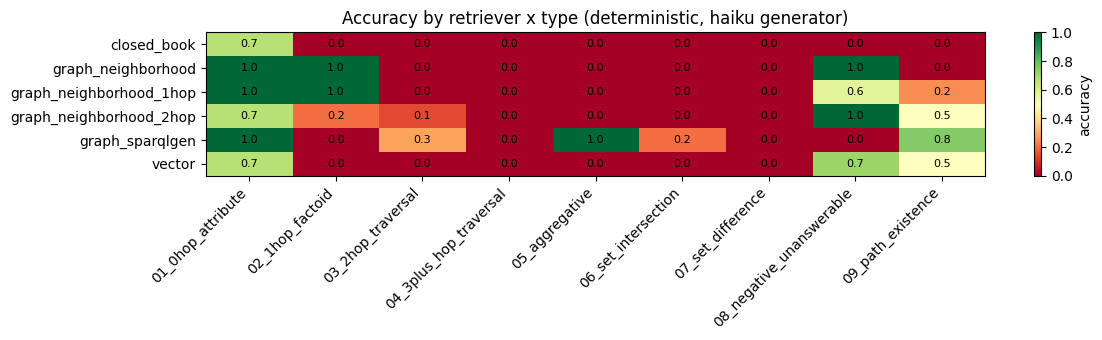

In [11]:
import matplotlib.pyplot as plt

# Step-2 figures characterize retrievers under the CANONICAL config: the haiku generator and (for
# graph_sparqlgen) the haiku SPARQL writer. The qwen-generator and sonnet-writer runs are separate
# comparison studies; with the writer now in the dedup grain, sparqlgen carries one row per writer,
# so a retriever-only aggregate would AVERAGE distinct conditions. Pin one coherent surface here and
# slice it in every figure below (the generator-comparison gets its own faceted figures).
canon = df[(df["generator_model_family"] == "claude-haiku-4-5")
           & (df["writer_model_family"].isna() | (df["writer_model_family"] == "claude-haiku-4-5"))]

det = canon[canon["scoring"] != "semantic"]
piv = det.pivot_table(index="retriever", columns="type_id", values="passed", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha="right")
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="accuracy"); ax.set_title("Accuracy by retriever x type (deterministic, haiku generator)")
plt.tight_layout()

### Fig 2 — Recall vs. exact-set pass (the `graph_sparqlgen` finding)

The set/aggregate judges pass only on an *exact* set; **recall** reveals how often the *complete*
answer was actually retrieved even when the binary verdict failed (precision leaks sink it).

,mean_recall,exact_pass_rate,n
retriever,,,
closed_book,0.07,0.00,30
graph_neighborhood,0.33,0.20,5
graph_neighborhood_1hop,0.32,0.17,30
graph_neighborhood_2hop,0.08,0.07,30
graph_sparqlgen,0.49,0.10,30
vector,0.00,0.00,30


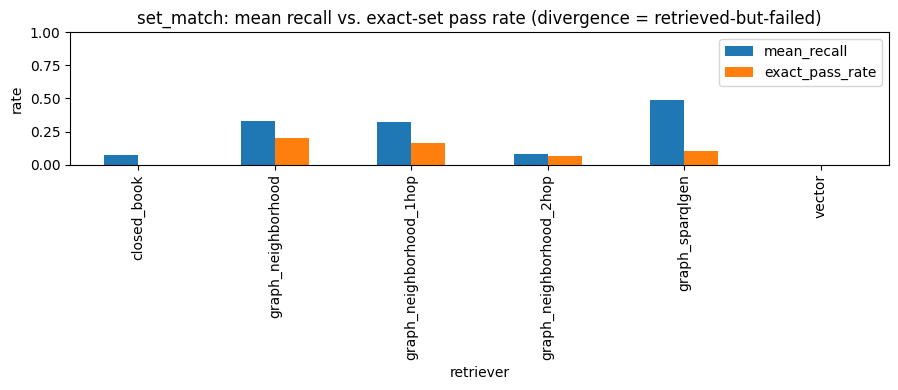

In [12]:
sm = canon[(canon["scoring"] == "set_match") & canon["recall"].notna()]
g = sm.groupby("retriever").agg(mean_recall=("recall", "mean"),
                                exact_pass_rate=("passed", "mean"),
                                n=("passed", "size"))
ax = g[["mean_recall", "exact_pass_rate"]].plot.bar(figsize=(9, 4))
ax.set_ylabel("rate"); ax.set_ylim(0, 1)
ax.set_title("set_match: mean recall vs. exact-set pass rate (divergence = retrieved-but-failed)")
plt.tight_layout()
g.round(2)

### Fig 3 — Precision leak on set questions

Where recall is high but extra rows sink F1 — `graph_sparqlgen`'s underconstrained queries return
supersets (worst on set-difference / 3+hop).

In [13]:
canon[canon["scoring"] == "set_match"].groupby("retriever").agg(
    recall=("recall", "mean"), precision=("precision", "mean"),
    f1=("f1", "mean"), mean_extra=("num_extra", "mean")).round(2)

,recall,precision,f1,mean_extra
retriever,,,,
closed_book,0.07,0.06,0.06,19.77
graph_neighborhood,0.33,0.38,0.39,2.20
graph_neighborhood_1hop,0.32,0.27,0.29,7.97
graph_neighborhood_2hop,0.08,0.15,0.14,7.73
graph_sparqlgen,0.49,0.55,0.56,2.77
vector,0.00,0.00,0.00,3.37


### Cost — retrieval token premium (writer cost pending re-run)

`retrieval_token_premium` = billed `input_tokens` − closed_book input for the same question+model
(the one unit-safe decomposition). `writer_in` is the `graph_sparqlgen` writer-LLM cost — `NaN`
until the re-runs, demonstrating the coverage gap rather than hiding it.

In [14]:
canon.groupby("retriever").agg(
    premium=("retrieval_token_premium", "mean"),
    writer_in=("writer_input_tokens", "mean")).round(1)

,premium,writer_in
retriever,,
closed_book,0.0,NaN
graph_neighborhood,868.4,NaN
graph_neighborhood_1hop,755.8,NaN
graph_neighborhood_2hop,2331.2,NaN
graph_sparqlgen,264.6,572.5
vector,737.6,NaN


### Next

- **Canonical re-runs** on the new telemetry schema populate the writer / top_k / cache / cosine
  columns and the full-corpus `vector` arm — these cells then refresh automatically.
- The **polished notebook** imports the same `load()` and refines these into the definitive figures
  (and adds the type-08 sensitivity panel and the type-10 *uncalibrated* note).